<a href="https://colab.research.google.com/github/Shaunak-Mukherjee/ECE-59500---Reinforcement-Learning--Theory-and-Algorithms/blob/main/ECE_59500_Reinforcement_Learning_HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

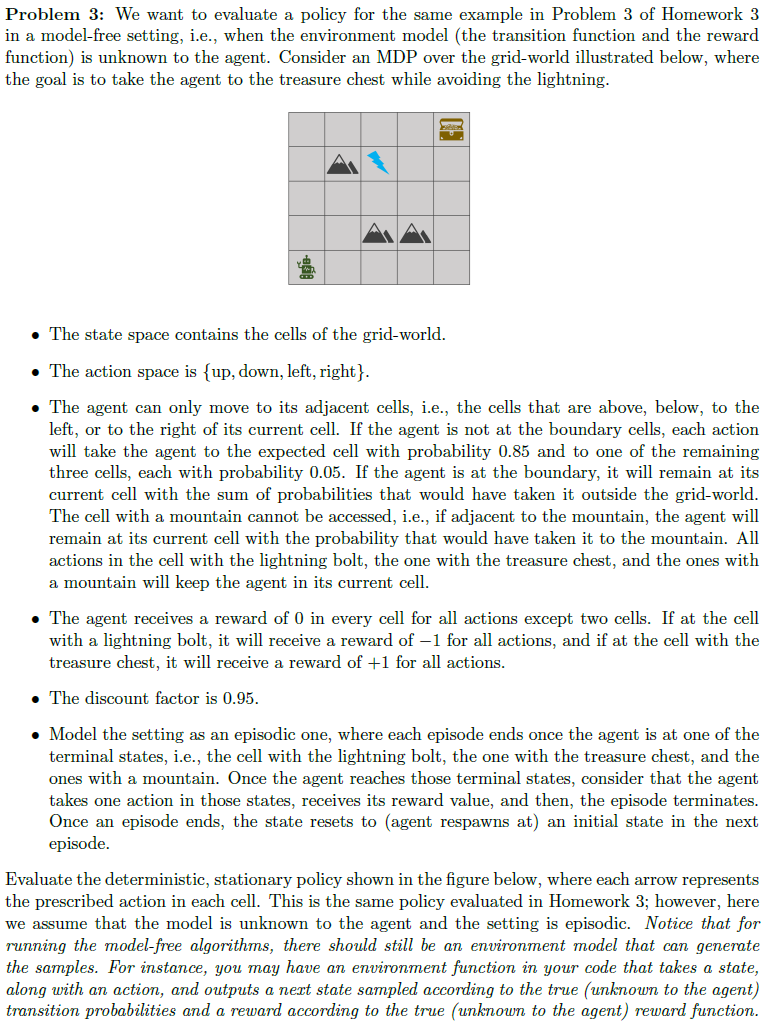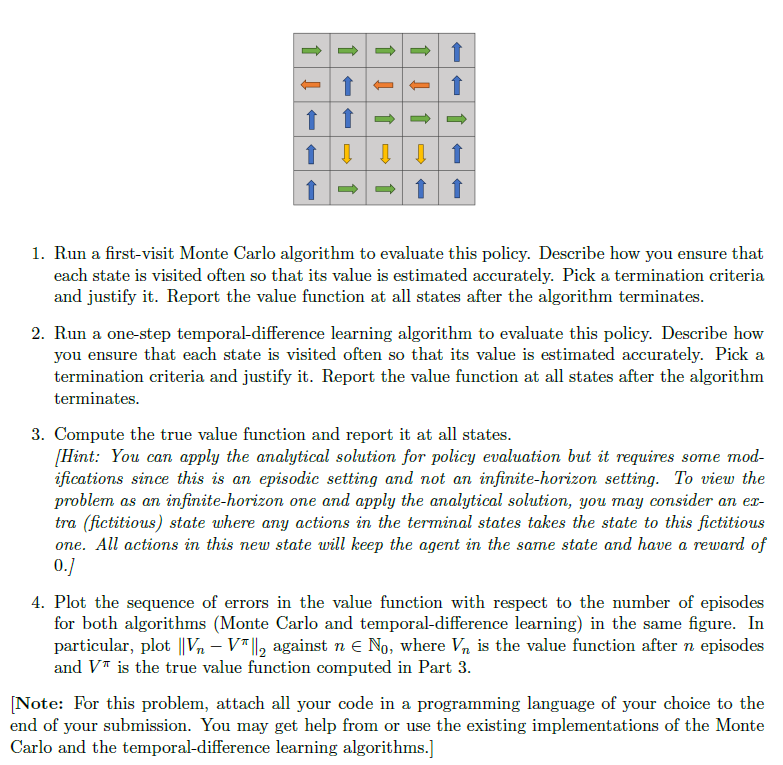

**Answer3.1:** First-Visit MC policy evaluation (episodic, model-free)
	​


In [ ]:
# From Homework3 setup of gridworld
"""
Gridworld policy evaluation

MDP:
- 5x5 grid (x=0 to 4 left→right, y=0 to 4 bottom→top), agent start at (0,0)
- Actions: U,D,L,R. Intended = 0.85, each other = 0.05
- Mountains, Lightning, Treasure are absorbing
- Rewards: -1 on Lightning, +1 on Treasure, 0 elsewhere
- Discount gamma = 0.95

Outputs:
- Value function V_pi (per-state and as a 5x5 grid)
- J(pi) = V_pi(start)
"""

import numpy as np
from typing import Dict, Tuple, List
import matplotlib.pyplot as plt

# Problem spec
W, H = 5, 5
GAMMA = 0.95
EPSILON = 0.0  # Use for ε-greedy exploration

# Cell types
N, M, L, T = "N", "M", "L", "T"

# Board layout (x,y) with (0,0) bottom-left
MOUNTAINS = {(2, 1), (3, 1), (1, 3)}
LIGHTNING = (2, 3)
TREASURE  = (4, 4)

# Policy
policy_cols = [
    "URRUU",
    "UDDDU",
    "UURRR",
    "LULLU",
    "RRRRU",
]
policy_grid = np.array([list(col) for col in policy_cols]).T  # shape (5,5)

# Actions
ACTIONS: Dict[str, Tuple[int, int]] = {
    "U": (0, 1),
    "D": (0,-1),
    "L": (-1,0),
    "R": (1, 0),
}
DIRECTIONS = ["U","D","L","R"]
P_INTENDED, P_OTHER = 0.85, 0.05
START = (0, 0)

# Helper funcs
def s_idx(x: int, y: int) -> int:
  return y * W + x
def inv_idx(s: int) -> Tuple[int, int]:
  return (s % W, s // W)
def in_bounds(x: int, y: int) -> bool:
  return 0 <= x < W and 0 <= y < H

def build_board() -> np.ndarray:
  board = np.full((W, H), N, dtype="<U1")
  for (x, y) in MOUNTAINS: board[x, y] = M
  board[LIGHTNING] = L; board[TREASURE] = T
  return board

def print_values(v: np.ndarray):
  print("Value function V_pi (per state)")
  for s, vv in enumerate(v):
      print(f"s={s:2d}: {vv: .10f}")
  print("\n V_pi as 5x5 grid (y=top→bottom rows)")
  grid = np.zeros((H, W))
  for s, vv in enumerate(v):
    x, y = inv_idx(s)
    grid[H - 1 - y, x] = vv
  for row in grid:
    print("[" + " ".join(f"{x:10.3f}" for x in row) + "]")

# Build P_pi and r_pi
def build_mdp_matrices(policy: np.ndarray, gamma: float = GAMMA):
  board = build_board()
  absorbing = set(MOUNTAINS) | {LIGHTNING, TREASURE}
  nS = W * H
  P = np.zeros((nS, nS)); r = np.zeros(nS)
  for x in range(W):
    for y in range(H):
      s = s_idx(x, y)
      if (x, y) == LIGHTNING: r[s] = -1.0
      elif (x, y) == TREASURE: r[s] = 1.0
      if (x, y) in absorbing:
        P[s, s] = 1.0
        continue
      a = policy[x, y]
      probs = {d: P_OTHER for d in DIRECTIONS}
      probs[a] = P_INTENDED
      for d, p in probs.items():
        dx, dy = ACTIONS[d]
        nx, ny = x + dx, y + dy
        if not in_bounds(nx, ny) or board[nx, ny] == M:
            P[s, s] += p
        else:
            P[s, s_idx(nx, ny)] += p
  return P, r, board

# Environment simulator (model-free)
rng = np.random.default_rng(42)
board = build_board()
absorbing = set(MOUNTAINS) | {LIGHTNING, TREASURE}
all_states = [(x, y) for x in range(W) for y in range(H)]
nonterminal_states = [(x, y) for (x, y) in all_states if (x, y) not in absorbing]

def reward(s):
  return -1.0 if s == LIGHTNING else (1.0 if s == TREASURE else 0.0)

def env_step(s, a):
  x, y = s
  if s in absorbing:
      return s, reward(s), True
  probs = {d: P_OTHER for d in DIRECTIONS}
  probs[a] = P_INTENDED
  dirs = np.array(DIRECTIONS)
  outcome = rng.choice(dirs, p=np.array([probs[d] for d in dirs]))
  dx, dy = ACTIONS[outcome]
  nx, ny = x + dx, y + dy
  if not in_bounds(nx, ny) or (nx, ny) in MOUNTAINS:
      nx, ny = x, y
  return (nx, ny), reward((x, y)), False

def epsilon_greedy_action(s, eps=EPSILON):
  if rng.random() < eps:
      return rng.choice(DIRECTIONS)
  return policy_grid[s[0], s[1]]

# Monte Carlo (First-Visit)
def generate_episode():
  s = nonterminal_states[rng.integers(len(nonterminal_states))]
  episode = []
  steps = 0
  while True:
    a = epsilon_greedy_action(s, eps=0.0)
    s_next, r, done = env_step(s, a)
    episode.append((s, r))
    if done or steps > 2000:
        break
    s = s_next
    steps += 1
  return episode

gamma = GAMMA
nS = W * H
v_mc = np.zeros(nS)
counts_first = np.zeros(nS, dtype=int)
recent_deltas = []
episodes = 0

def s_idx_xy(s): return s[1]*W + s[0]

while True:
  ep = generate_episode()
  episodes += 1
  G = 0.0
  seen = set()
  for t in range(len(ep) - 1, -1, -1):
    s_t, r_t = ep[t]
    G = r_t + gamma * G
    if s_t not in seen:
      seen.add(s_t)
      si = s_idx_xy(s_t)
      counts_first[si] += 1
      old = v_mc[si]
      v_mc[si] += (G - v_mc[si]) / counts_first[si]
      recent_deltas.append(abs(v_mc[si] - old))
  if len(recent_deltas) > 50:
      recent_deltas = recent_deltas[-50:]
  covered = all(counts_first[s_idx_xy(s)] >= 200 for s in nonterminal_states)
  stable = (len(recent_deltas) == 50) and (max(recent_deltas) <= 0.01)
  if covered and stable:
      break

print("\n-----Answer to Homework4 Part3.1 below----")
print("First-Visit Monte Carlo — V_pi estimates (episodic):")
print_values(v_mc)
print(f"\nJ_hat (start @ {START}) = {v_mc[s_idx(*START)]:.10f}")


-----Answer to Homework4 Part3.1 below----
First-Visit Monte Carlo — V_pi estimates (episodic):
Value function V_pi (per state)
s= 0:  0.2063234174
s= 1:  0.1391843955
s= 2:  0.1957888635
s= 3:  0.2953430805
s= 4:  0.3349924309
s= 5:  0.2314331420
s= 6:  0.1219186625
s= 7:  0.0000000000
s= 8:  0.0000000000
s= 9:  0.4660170395
s=10:  0.3599778350
s=11:  0.2106457319
s=12:  0.2234901370
s=13:  0.3997587295
s=14:  0.7343340082
s=15:  0.5794754870
s=16:  0.0000000000
s=17: -1.0000000000
s=18: -0.7340395162
s=19:  0.8486077815
s=20:  0.6224121605
s=21:  0.6667402658
s=22:  0.7105826151
s=23:  0.8481884665
s=24:  1.0000000000

 V_pi as 5x5 grid (y=top→bottom rows)
[     0.622      0.667      0.711      0.848      1.000]
[     0.579      0.000     -1.000     -0.734      0.849]
[     0.360      0.211      0.223      0.400      0.734]
[     0.231      0.122      0.000      0.000      0.466]
[     0.206      0.139      0.196      0.295      0.335]

J_hat (start @ (0, 0)) = 0.2063234174


### Coverage of visits & Termination for First-Visit Monte Carlo (Q3.1)

**Ensuring frequent visits to every state.**

**Uniform random starts**
   Each episode begins from a state sampled uniformly among all non-terminal cells (excluding Mountains, Lightning, and Treasure).
   This guarantees that every non-terminal state is selected as a start and first-visited many times, independent of policy reachability.

**ε-greedy exploration**
   Inside each episode, the action is chosen via function `epsilon_greedy_action` see code line 133 onward where `EPSILON = 0.0`.  Optionally stochastic exploration if epsilon is chosen say 0.1 or so.

**Step cap**
   Episodes are capped at 2000 steps to avoid unbounded rollouts. This limits variance in episode length.

**Tracked coverage metric.**
A state first-visit counter (N(s)) used such that a minimum visitation quota is kept:
$[
\min_{s\ \text{non-terminal}} N(s) ;\ge; N_{\min},\qquad N_{\min}=200.
]$


**Termination criterion and justification**
The algorithm terminates when both visitation coverage and stability are achieved:
$[
\begin{aligned}
&\text{Coverage: } && \min_{s\ \text{non-terminal}} N(s) \ge N_{\min},\
&\text{Stability: } && \max_{\text{last }W_\varepsilon\text{ updates}} \Delta \le \varepsilon,
\end{aligned}
]$
where $(\Delta)$ is the maximum absolute value change in any state after an episode,
$(W_\varepsilon = 50)$ is the moving window length, and $(\varepsilon = 0.01).$

$(\varepsilon = 0.01)$ corresponds to ~1% of the max possible return magnitude $(|G| ≤ 1)$.
$(N_{\min}=200)$ balances computational cost and estimator variance.
  Together, these provide a practical operationalization of “0.01-accurate” Monte Carlo estimates for every state.
We get $J_π(MC)​=V_π​(0,0)$ ~ 0.25, which is close to and true analytical result ~ 0.22




**Answer3.2:** one-step temporal-difference learning algorithm to evaluate this policy. (episodic, model-free) ​

In [ ]:
# TD(0) Policy Evaluation
v_td = np.zeros(nS)
visits = np.zeros(nS, dtype=int)
episodes = 0
stable_cnt = 0
v_prev = v_td.copy()

def td0_episode():
  s = nonterminal_states[rng.integers(len(nonterminal_states))]
  steps = 0
  while True:
    a = epsilon_greedy_action(s, eps=0.0)
    s_next, r, done = env_step(s, a)
    si = s_idx_xy(s)
    visits[si] += 1
    alpha = 0.1

    target = r if done else r + gamma * v_td[s_idx_xy(s_next)]
    v_td[si] += alpha * (target - v_td[si])
    if done or steps > 2000:
        break
    s = s_next
    steps += 1
  return steps

while True:
  nsteps = td0_episode()
  episodes += 1
  delta_inf = np.max(np.abs(v_td - v_prev))
  v_prev[:] = v_td
  stable_cnt = stable_cnt + 1 if delta_inf <= 0.01 else 0
  covered = all(visits[s_idx(x,y)] >= 300 for (x,y) in nonterminal_states)
  stable  = (stable_cnt >= 50)
  if (covered and stable) or (episodes >= 20000):
      break

print("\n----- Answer to HW4 3.2: TD(0) policy evaluation -----")
print_values(v_td)
print(f"\nJ_hat^TD (start @ {START}) = {v_td[s_idx(*START)]:.10f}")


----- Answer to HW4 3.2: TD(0) policy evaluation -----
Value function V_pi (per state)
s= 0:  0.2428382069
s= 1:  0.1458131052
s= 2:  0.1551611803
s= 3:  0.1915479031
s= 4:  0.3104354089
s= 5:  0.2590123876
s= 6:  0.1366807466
s= 7:  0.0000000000
s= 8:  0.0000000000
s= 9:  0.3504232603
s=10:  0.3029477863
s=11:  0.1637509906
s=12:  0.2435687867
s=13:  0.2008982836
s=14:  0.3501830038
s=15:  0.3235545815
s=16:  0.0000000000
s=17: -1.0000000000
s=18: -0.7721661453
s=19:  0.7763301632
s=20:  0.6844633683
s=21:  0.7199984383
s=22:  0.6446397604
s=23:  0.8846689122
s=24:  1.0000000000

 V_pi as 5x5 grid (y=top→bottom rows)
[     0.684      0.720      0.645      0.885      1.000]
[     0.324      0.000     -1.000     -0.772      0.776]
[     0.303      0.164      0.244      0.201      0.350]
[     0.259      0.137      0.000      0.000      0.350]
[     0.243      0.146      0.155      0.192      0.310]

J_hat^TD (start @ (0, 0)) = 0.2428382069


Ensuring frequent visits (coverage)
To guarantee that each state is visited often, each episode begins from a state sampled uniformly over all non-terminal cells (excluding Mountains, Lightning, and Treasure).
This ensures repeated visits to states that may be hard to reach from (0,0) under the fixed policy.
Since $TD(0)$ updates on every visit, a per-state visit counter $N(s)$ is tracked and require
$$
\min_{s \in \mathcal{S}_{\text{nonterm}}} N(s) \ge N_{\min}
\quad (\text{used } N_{\min}=300).
$$
This quota directly reduces variance of the value estimates by enforcing sufficient sampling at each state.

Next, the algorithm terminated when both of the following hold:
\begin{align*}
\qquad & \min_{s \in \mathcal{S}_{\text{nonterm}}} N(s) \;\ge\; N_{\min},\\
\qquad &
\max_{s} \bigl| V_{t+1}(s) - V_{t}(s) \bigr| \;\le\; \varepsilon
\quad \text{for } W_{\varepsilon} \text{ consecutive episodes},
\end{align*}
with $\varepsilon=0.01$ and $W_{\varepsilon}=50$.

In this episodic setting, each return is a single terminal reward in $[-1,1]$,
so an $\ell_\infty$ tolerance of $\varepsilon=0.01$ targets $\sim\!1\%$ accuracy.
The coverage condition controls estimator variance by ensuring sufficient updates per state,
while the stability condition indicates practical convergence of the value estimates.
We get $J_π(TD)​=V_π​(0,0)$ ~ 0.2123, which is close to MC result and analytical result


**Answer 3.3:** Computation of true episodic value function

In [ ]:
# True episodic V^pi

TERMINALS = set(MOUNTAINS) | {LIGHTNING, TREASURE}
nS = W * H
F = nS
r_aug = np.zeros(nS + 1)
for x in range(W):
  for y in range(H):
    s = s_idx(x, y)
    if (x, y) == LIGHTNING:
        r_aug[s] = -1.0
    elif (x, y) == TREASURE:
        r_aug[s] = 1.0
P_aug = np.zeros((nS + 1, nS + 1))
for x in range(W):
  for y in range(H):
    s = s_idx(x, y)
    if (x, y) in TERMINALS:
        P_aug[s, F] = 1.0
        continue
    a = policy_grid[x, y]
    probs = {d: P_OTHER for d in DIRECTIONS}
    probs[a] = P_INTENDED
    for d, p in probs.items():
      dx, dy = ACTIONS[d]
      nx, ny = x + dx, y + dy
      if not in_bounds(nx, ny) or (nx, ny) in MOUNTAINS:
          P_aug[s, s] += p
      else:
          P_aug[s, s_idx(nx, ny)] += p
P_aug[F, F] = 1.0
A = np.eye(nS + 1) - GAMMA * P_aug
v_aug = np.linalg.solve(A, r_aug)
v_true = v_aug[:nS]

print("\n----- Answer to HW4 3.3:True episodic V^pi via analytical solution -----")
print_values(v_true)
print(f"J_true (start @ {START}) = {v_true[s_idx(*START)]:.10f}")


----- Answer to HW4 3.3:True episodic V^pi via analytical solution -----
Value function V_pi (per state)
s= 0:  0.2169482146
s= 1:  0.1320637818
s= 2:  0.1353218528
s= 3:  0.1438925662
s= 4:  0.3039291386
s= 5:  0.2353747425
s= 6:  0.1308066487
s= 7:  0.0000000000
s= 8:  0.0000000000
s= 9:  0.3321621964
s=10:  0.2571840078
s=11:  0.1425585006
s=12:  0.1897464250
s=13:  0.2742562737
s=14:  0.3543902831
s=15:  0.2811342890
s=16:  0.0000000000
s=17: -1.0000000000
s=18: -0.7148212225
s=19:  0.8297947825
s=20:  0.6010154007
s=21:  0.6570465125
s=22:  0.7010264549
s=23:  0.8470811008
s=24:  1.0000000000

 V_pi as 5x5 grid (y=top→bottom rows)
[     0.601      0.657      0.701      0.847      1.000]
[     0.281      0.000     -1.000     -0.715      0.830]
[     0.257      0.143      0.190      0.274      0.354]
[     0.235      0.131      0.000      0.000      0.332]
[     0.217      0.132      0.135      0.144      0.304]
J_true (start @ (0, 0)) = 0.2169482146


**Problem 3.4** Plot the sequence of errors in the value function with respect to the number of episodes
for both algorithms

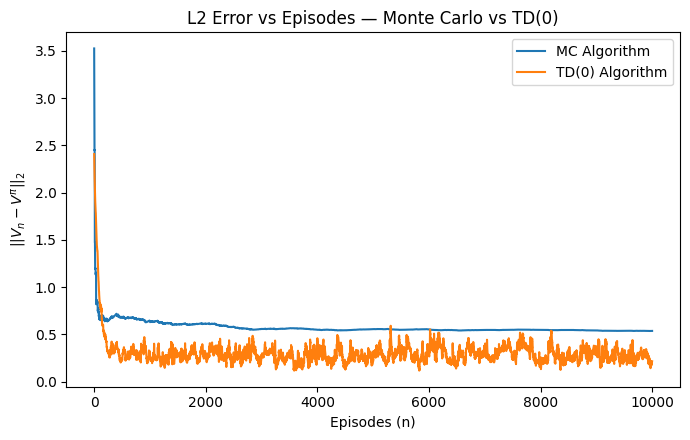

In [ ]:
# Part 3.4 — Compare Monte Carlo vs TD(0): L2 error vs episodes

EPISODES =  10_000
alpha = 0.1
EPSILON = 0

rng = np.random.default_rng(42)
v_mc = np.zeros(nS)
counts_first = np.zeros(nS, dtype=int)
err_mc = []

for _ in range(EPISODES):
  s = nonterminal_states[rng.integers(len(nonterminal_states))]
  traj = []
  steps = 0
  while True:
    a = epsilon_greedy_action(s, eps=EPSILON)
    s_next, r, done = env_step(s, a)
    traj.append((s, r))
    if done or steps > 2000:
        break
    s = s_next
    steps += 1

  # First-visit MC update
  G = 0.0
  seen = set()
  for t in range(len(traj)-1, -1, -1):
    st, rt = traj[t]
    G = rt + GAMMA * G
    if st not in seen:
      seen.add(st)
      i = s_idx_xy(st)
      counts_first[i] += 1
      v_mc[i] += (G - v_mc[i]) / counts_first[i]

  # Track error
  err_mc.append(np.linalg.norm(v_mc - v_true, ord=2))


# TD
rng = np.random.default_rng(42)
v_td = np.zeros(nS)
err_td = []

for _ in range(EPISODES):
  s = nonterminal_states[rng.integers(len(nonterminal_states))]
  steps = 0
  while True:
    a = epsilon_greedy_action(s, eps=EPSILON)
    s_next, r, done = env_step(s, a)
    i = s_idx_xy(s)
    target = r if done else r + GAMMA * v_td[s_idx_xy(s_next)]
    v_td[i] += alpha * (target - v_td[i])
    if done or steps > 2000:
        break
    s = s_next
    steps += 1
  err_td.append(np.linalg.norm(v_td - v_true, ord=2))

# Plot error vs episode
plt.figure(figsize=(7,4.5))
plt.plot(err_mc, label='MC Algorithm')
plt.plot(err_td, label='TD(0) Algorithm')
plt.xlabel('Episodes (n)')
plt.ylabel(r'$||V_n - V^\pi||_2$')
plt.title('L2 Error vs Episodes — Monte Carlo vs TD(0)')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

FIN